СОЗДАНИЕ ИНТЕРАКТИВНОГО ДАШБОРДА
ШВЕЙНОЕ ПРОИЗВОДСТВО - АНАЛИЗ ВОЗВРАТОВ

📂 Загрузка данных...
✅ Данные загружены: 101,089 транзакций

📊 Расчет KPI...
   • Выручка: 778.3M руб
   • Возвраты: 50.9%
   • Средний чек: 7699 руб

📊 Анализ возвратов...

📊 ABC-XYZ анализ...
   • Матрица ABC-XYZ готова

📊 RFM сегментация...
   • Клиентов сегментировано: 13,033

🤖 Обучение модели прогнозирования...
   • Модель обучена, важнейший признак: product_type_name

🎨 Создание дашборда...

📊 ТОП-10 ПРОБЛЕМНЫХ КОМБИНАЦИЙ:
   • Dress размер 44: 75.4% (1610 заказов)
   • Dress размер 40: 74.0% (1837 заказов)
   • Dress размер 50: 73.7% (1792 заказов)
   • Dress размер 42: 73.6% (2436 заказов)
   • Dress размер 48: 72.7% (1997 заказов)
   • Dress размер 46: 72.2% (1978 заказов)
   • Jacket размер 44: 59.3% (1216 заказов)
   • Jacket размер 52: 58.7% (1377 заказов)
   • Blouse размер 44: 58.3% (1369 заказов)
   • Blouse размер 40: 58.2% (1985 заказов)
✅ График добавлен на дашборд!

✅ Дашборд сохранён: dashboa

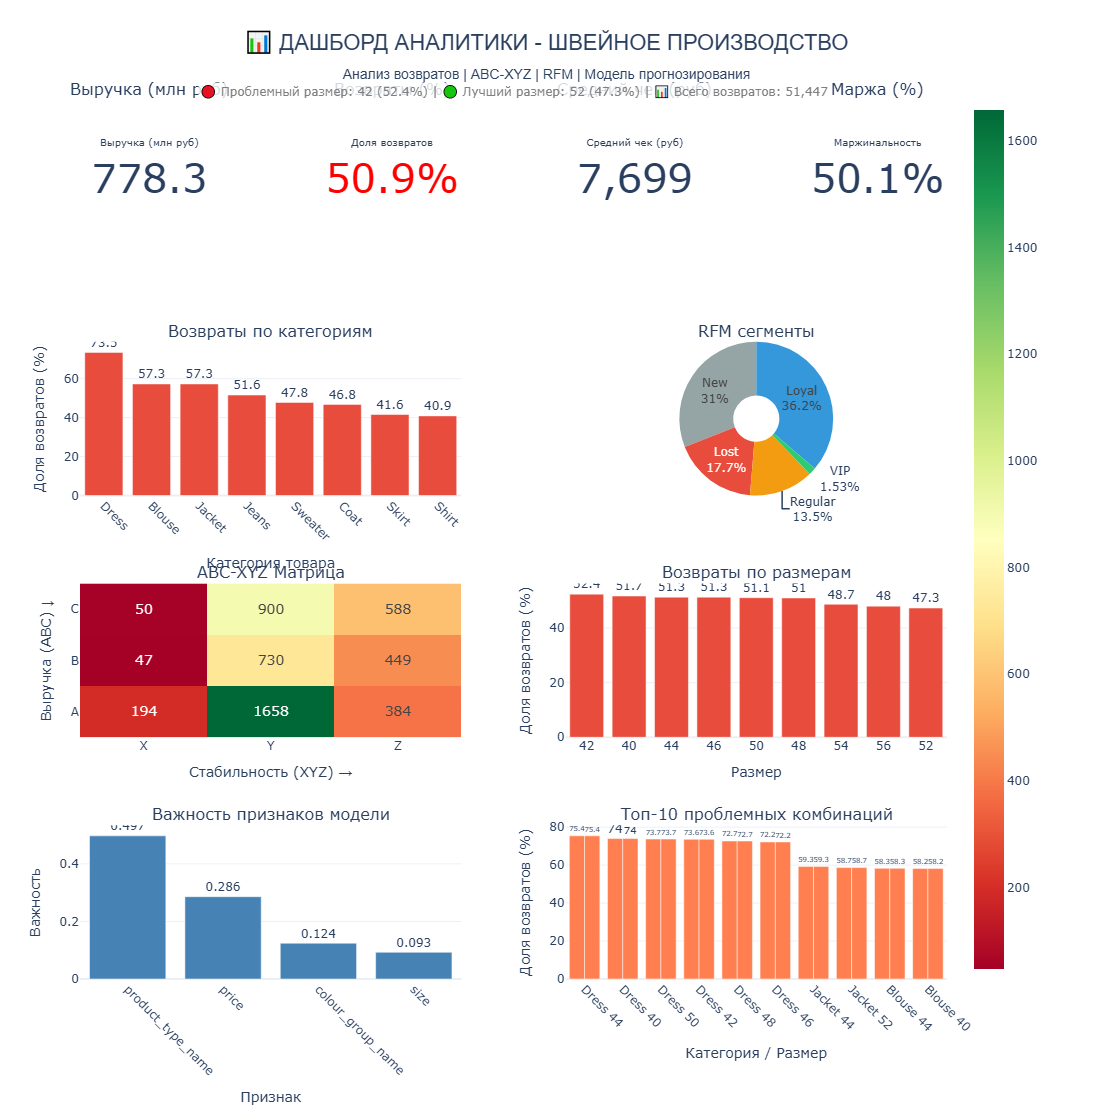


ДАШБОРД ГОТОВ!

📊 ИТОГОВЫЕ МЕТРИКИ ДАШБОРДА:

1. KPI:
   • Выручка: 778.3 млн руб
   • Возвраты: 50.9%
   • Средний чек: 7699 руб
   • Маржа: 50.1%

2. КЛИЕНТЫ:
   • Всего клиентов: 13,033
   • VIP: 199
   • Loyal: 4724

3. ТОВАРЫ:
   • A-товаров: 2236
   • AX (золото): 194
   • CZ (неликвид): 588

4. ПРОБЛЕМНЫЕ РАЗМЕРЫ:
   • Худший: 42 (52.4% возвратов)
   • Лучший: 52 (47.3% возвратов)



In [1]:
# Установка (если нет)
# pip install pandas numpy plotly kaleido scikit-learn

import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("СОЗДАНИЕ ИНТЕРАКТИВНОГО ДАШБОРДА")
print("ШВЕЙНОЕ ПРОИЗВОДСТВО - АНАЛИЗ ВОЗВРАТОВ")
print("=" * 80)

# ============================================
# 1. ЗАГРУЗКА ДАННЫХ
# ============================================
print("\n📂 Загрузка данных...")

transactions = pd.read_csv('transactions.csv', sep=';', encoding='utf-8', decimal=',')
articles = pd.read_csv('articles.csv', sep=';', encoding='utf-8', decimal=',')
customers = pd.read_csv('customers.csv', sep=';', encoding='utf-8', decimal=',')

transactions['t_dat'] = pd.to_datetime(transactions['t_dat'])
if 'return_date' in transactions.columns:
    transactions['return_date'] = pd.to_datetime(transactions['return_date'])

transactions['size'] = transactions['size'].astype(str)
articles['size'] = articles['size'].astype(str)

print(f"✅ Данные загружены: {len(transactions):,} транзакций")

# ============================================
# 2. РАСЧЕТ KPI
# ============================================
print("\n📊 Расчет KPI...")

total_revenue = transactions['price'].sum()
total_orders = len(transactions)
total_returns = transactions['is_returned'].sum()
return_rate = total_returns / total_orders * 100
avg_check = transactions['price'].mean()

if 'margin' in transactions.columns:
    total_margin = transactions['margin'].sum()
    margin_rate = total_margin / total_revenue * 100
else:
    total_margin = total_revenue * 0.3
    margin_rate = 30

unique_customers = transactions[transactions['customer_id'] > 0]['customer_id'].nunique()
repeat_rate = len(transactions[transactions['customer_id'] > 0].groupby('customer_id').filter(lambda x: len(x) > 1)['customer_id'].unique()) / unique_customers * 100 if unique_customers > 0 else 0

print(f"   • Выручка: {total_revenue/1_000_000:.1f}M руб")
print(f"   • Возвраты: {return_rate:.1f}%")
print(f"   • Средний чек: {avg_check:.0f} руб")

# ============================================
# 3. АНАЛИЗ ВОЗВРАТОВ ПО КАТЕГОРИЯМ И РАЗМЕРАМ
# ============================================
print("\n📊 Анализ возвратов...")

# По категориям
cat_returns = transactions.groupby('product_type_name').agg({
    'article_id': 'count',
    'is_returned': ['sum', 'mean'],
    'price': 'sum'
}).round(3)
cat_returns.columns = ['orders', 'returns', 'return_rate', 'revenue']
cat_returns['return_rate'] = cat_returns['return_rate'] * 100
cat_returns = cat_returns.sort_values('return_rate', ascending=False)

# По размерам
size_returns = transactions.groupby('size').agg({
    'article_id': 'count',
    'is_returned': ['sum', 'mean']
}).round(3)
size_returns.columns = ['orders', 'returns', 'return_rate']
size_returns['return_rate'] = size_returns['return_rate'] * 100
size_returns = size_returns.sort_values('return_rate', ascending=False)

# По типу × размер - ИСПРАВЛЕНО: СРАЗУ ДЕЛАЕМ ПРАВИЛЬНО!
size_type_returns = transactions.groupby(['product_type_name', 'size']).agg(
    orders=('article_id', 'count'),
    return_rate=('is_returned', 'mean')
).reset_index()  # <-- ВОТ ЭТО КЛЮЧЕВОЕ ИЗМЕНЕНИЕ!
size_type_returns['return_rate'] = size_type_returns['return_rate'] * 100
size_type_returns = size_type_returns[size_type_returns['orders'] > 30]


# ============================================
# 4. ABC-XYZ АНАЛИЗ (ИСПРАВЛЕН)
# ============================================
print("\n📊 ABC-XYZ анализ...")

product_sales = transactions.groupby('article_id').agg({
    'price': 'sum',
    't_dat': 'count'
}).rename(columns={'price': 'revenue', 't_dat': 'freq'})

product_sales = product_sales.sort_values('revenue', ascending=False)
product_sales['cumsum_pct'] = product_sales['revenue'].cumsum() / product_sales['revenue'].sum() * 100

def abc_classify(pct):
    if pct <= 70:
        return 'A'
    elif pct <= 90:
        return 'B'
    else:
        return 'C'

product_sales['abc'] = product_sales['cumsum_pct'].apply(abc_classify)

# ИСПРАВЛЕНО: преобразуем в строку
product_sales['xyz'] = pd.cut(product_sales['freq'], bins=3, labels=['Z', 'Y', 'X']).astype(str)
product_sales['abc_xyz'] = product_sales['abc'] + product_sales['xyz']

matrix = pd.crosstab(product_sales['abc'], product_sales['xyz'])
for abc in ['A', 'B', 'C']:
    if abc not in matrix.index:
        matrix.loc[abc] = 0
for xyz in ['X', 'Y', 'Z']:
    if xyz not in matrix.columns:
        matrix[xyz] = 0
matrix = matrix.reindex(['A', 'B', 'C'])[['X', 'Y', 'Z']]

print(f"   • Матрица ABC-XYZ готова")

# ============================================
# 5. RFM СЕГМЕНТАЦИЯ
# ============================================
print("\n📊 RFM сегментация...")

last_date = transactions['t_dat'].max()
rfm = transactions[transactions['customer_id'] > 0].groupby('customer_id').agg({
    't_dat': lambda x: (last_date - x.max()).days,
    'article_id': 'count',
    'price': 'sum'
}).rename(columns={'t_dat': 'recency', 'article_id': 'frequency', 'price': 'monetary'})

def segment_customer(row):
    if row['frequency'] >= 5 and row['monetary'] >= 50000:
        return 'VIP'
    elif row['frequency'] >= 3:
        return 'Loyal'
    elif row['frequency'] == 1:
        return 'New'
    elif row['recency'] > 90:
        return 'Lost'
    else:
        return 'Regular'

rfm['segment'] = rfm.apply(segment_customer, axis=1)
segment_counts = rfm['segment'].value_counts()

print(f"   • Клиентов сегментировано: {len(rfm):,}")

# ============================================
# 6. МОДЕЛЬ ПРОГНОЗИРОВАНИЯ
# ============================================
print("\n🤖 Обучение модели прогнозирования...")

model_data = transactions.sample(min(20000, len(transactions)), random_state=42)
features = ['price', 'product_type_name', 'size', 'colour_group_name']

X = model_data[features].copy()
y = model_data['is_returned'].copy()

for col in ['product_type_name', 'size', 'colour_group_name']:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

model = RandomForestClassifier(n_estimators=50, max_depth=8, random_state=42, n_jobs=-1)
model.fit(X, y)

importance = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print(f"   • Модель обучена, важнейший признак: {importance.iloc[0]['feature']}")

# ============================================
# 7. СОЗДАНИЕ ДАШБОРДА
# ============================================
print("\n🎨 Создание дашборда...")

fig = make_subplots(
    rows=4, cols=4,
    specs=[
        [{"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}],
        [{"type": "bar", "colspan": 2}, None, {"type": "pie", "colspan": 2}, None],
        [{"type": "heatmap", "colspan": 2}, None, {"type": "bar", "colspan": 2}, None],
        [{"type": "bar", "colspan": 2}, None, {"type": "bar", "colspan": 2}, None]
    ],
    subplot_titles=(
        'Выручка (млн руб)', 'Возвраты (%)', 'Средний чек (руб)', 'Маржа (%)',
        'Возвраты по категориям', 'RFM сегменты',
        'ABC-XYZ Матрица', 'Возвраты по размерам',
        'Важность признаков модели', 'Топ-10 проблемных комбинаций'
    ),
    vertical_spacing=0.10,
    horizontal_spacing=0.12
)

# KPI 1: Выручка
fig.add_trace(
    go.Indicator(mode="number", value=total_revenue/1_000_000,
                 number={"valueformat": ".1f", "font": {"size": 40}},
                 title={"text": "Выручка (млн руб)"}),
    row=1, col=1
)

# KPI 2: Возвраты
color = "red" if return_rate > 20 else "orange" if return_rate > 10 else "green"
fig.add_trace(
    go.Indicator(mode="number", value=return_rate,
                 number={"valueformat": ".1f", "suffix": "%", "font": {"size": 40, "color": color}},
                 title={"text": "Доля возвратов"}),
    row=1, col=2
)

# KPI 3: Средний чек
fig.add_trace(
    go.Indicator(mode="number", value=avg_check,
                 number={"valueformat": ",.0f", "font": {"size": 40}},
                 title={"text": "Средний чек (руб)"}),
    row=1, col=3
)

# KPI 4: Маржа
fig.add_trace(
    go.Indicator(mode="number", value=margin_rate,
                 number={"valueformat": ".1f", "suffix": "%", "font": {"size": 40}},
                 title={"text": "Маржинальность"}),
    row=1, col=4
)

# График 1: Возвраты по категориям
top_cats = cat_returns.head(8)
colors_cats = ['#e74c3c' if x > 25 else '#f39c12' if x > 15 else '#2ecc71' for x in top_cats['return_rate']]
fig.add_trace(
    go.Bar(x=top_cats.index, y=top_cats['return_rate'],
           marker_color=colors_cats, name='Возвраты %',
           text=top_cats['return_rate'].round(1), textposition='outside'),
    row=2, col=1
)

# График 2: RFM сегменты
colors_seg = {'VIP': '#2ecc71', 'Loyal': '#3498db', 'Regular': '#f39c12', 'New': '#95a5a6', 'Lost': '#e74c3c'}
fig.add_trace(
    go.Pie(labels=segment_counts.index, values=segment_counts.values,
           marker=dict(colors=[colors_seg.get(s, '#95a5a6') for s in segment_counts.index]),
           hole=0.3, textinfo='label+percent'),
    row=2, col=3
)

# График 3: ABC-XYZ Матрица
fig.add_trace(
    go.Heatmap(z=matrix.values, x=['X', 'Y', 'Z'], y=['A', 'B', 'C'],
               text=matrix.values, texttemplate='%{text}', textfont={"size": 14},
               colorscale='RdYlGn', showscale=True, name='Товаров'),
    row=3, col=1
)

# График 4: Возвраты по размерам
top_sizes = size_returns.head(10)
colors_sizes = ['#e74c3c' if x > 20 else '#f39c12' if x > 10 else '#2ecc71' for x in top_sizes['return_rate']]
fig.add_trace(
    go.Bar(x=top_sizes.index, y=top_sizes['return_rate'],
           marker_color=colors_sizes, name='Возвраты %',
           text=top_sizes['return_rate'].round(1), textposition='outside'),
    row=3, col=3
)

# График 5: Важность признаков
fig.add_trace(
    go.Bar(x=importance['feature'], y=importance['importance'],
           marker_color='steelblue', name='Важность',
           text=importance['importance'].round(3), textposition='outside'),
    row=4, col=1
)

# График 6: Топ-10 проблемных комбинаций
top_problems = size_type_returns.nlargest(10, 'return_rate').copy()
top_problems['combo'] = top_problems['product_type_name'].astype(str).str[:12] + '\n' + top_problems['size'].astype(str)

fig.add_trace(
    go.Bar(
        x=top_problems['combo'],
        y=top_problems['return_rate'],
        marker_color='coral',
        name='Возвраты %',
        text=top_problems['return_rate'].round(1),
        textposition='outside',
        hovertemplate='<b>%{x}</b><br>Возвраты: %{y:.1f}%<br>Заказов: %{customdata}<extra></extra>',
        customdata=top_problems['orders']
    ),
    row=4, col=3
)

# ============================================
# ТОП-10 ПРОБЛЕМНЫХ КОМБИНАЦИЙ
# ============================================
top_problems = size_type_returns.nlargest(10, 'return_rate').copy()

# Создаем подписи
top_problems['combo'] = top_problems['product_type_name'].astype(str).str[:12] + '\n' + top_problems['size'].astype(str)

print(f"\n📊 ТОП-10 ПРОБЛЕМНЫХ КОМБИНАЦИЙ:")
for i, row in top_problems.iterrows():
    print(f"   • {row['product_type_name']} размер {row['size']}: {row['return_rate']:.1f}% ({row['orders']} заказов)")

# ============================================
# ДОБАВЛЯЕМ НА ДАШБОРД
# ============================================
fig.add_trace(
    go.Bar(
        x=top_problems['combo'],
        y=top_problems['return_rate'],
        marker_color='coral',
        name='Возвраты %',
        text=top_problems['return_rate'].round(1),
        textposition='outside',
        textfont=dict(size=10),
        hovertemplate='<b>%{x}</b><br>Возвраты: %{y:.1f}%<br>Заказов: %{customdata:,}<extra></extra>',
        customdata=top_problems['orders']
    ),
    row=4, col=3
)

print("✅ График добавлен на дашборд!")


# ============================================
# 8. НАСТРОЙКА LAYOUT
# ============================================
fig.update_layout(
    title={
        'text': "📊 ДАШБОРД АНАЛИТИКИ - ШВЕЙНОЕ ПРОИЗВОДСТВО<br>"
                "<span style='font-size:14px'>Анализ возвратов | ABC-XYZ | RFM | Модель прогнозирования</span>",
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 22, 'family': 'Arial'}
    },
    height=1100,
    width=1400,
    showlegend=False,
    template='plotly_white'
)

# Настройка осей
fig.update_xaxes(title_text="Категория товара", row=2, col=1, tickangle=45)
fig.update_xaxes(title_text="Стабильность (XYZ) →", row=3, col=1)
fig.update_xaxes(title_text="Размер", row=3, col=3)
fig.update_xaxes(title_text="Признак", row=4, col=1, tickangle=45)
fig.update_xaxes(title_text="Категория / Размер", row=4, col=3, tickangle=45)

fig.update_yaxes(title_text="Доля возвратов (%)", row=2, col=1)
fig.update_yaxes(title_text="Выручка (ABC) ↓", row=3, col=1)
fig.update_yaxes(title_text="Доля возвратов (%)", row=3, col=3)
fig.update_yaxes(title_text="Важность", row=4, col=1)
fig.update_yaxes(title_text="Доля возвратов (%)", row=4, col=3)

fig.update_xaxes(type='category', row=4, col=3)  # <-- ДОБАВЬТЕ ЭТО

# Добавляем аннотацию с выводами
worst_size = size_returns.index[0] if len(size_returns) > 0 else 'N/A'
worst_rate = size_returns.iloc[0]['return_rate'] if len(size_returns) > 0 else 0
best_size = size_returns.index[-1] if len(size_returns) > 0 else 'N/A'
best_rate = size_returns.iloc[-1]['return_rate'] if len(size_returns) > 0 else 0

fig.add_annotation(
    text=f"🔴 Проблемный размер: {worst_size} ({worst_rate:.1f}%) | "
         f"🟢 Лучший размер: {best_size} ({best_rate:.1f}%) | "
         f"📊 Всего возвратов: {total_returns:,}",
    xref="paper", yref="paper", x=0.5, y=1.02, showarrow=False,
    font=dict(size=12, color="gray"), bgcolor="rgba(255,255,255,0.8)"
)

# ============================================
# 9. СОХРАНЕНИЕ
# ============================================
fig.write_html('dashboard_fashion.html')
print("\n✅ Дашборд сохранён: dashboard_fashion.html")

try:
    fig.write_image('dashboard_fashion.png', width=1400, height=1100, scale=2)
    print("✅ PNG сохранён: dashboard_fashion.png")
except:
    print("⚠️ Для PNG нужен kaleido: pip install kaleido")

fig.show()

print("\n" + "=" * 80)
print("ДАШБОРД ГОТОВ!")
print("=" * 80)

print(f"""
📊 ИТОГОВЫЕ МЕТРИКИ ДАШБОРДА:

1. KPI:
   • Выручка: {total_revenue/1_000_000:.1f} млн руб
   • Возвраты: {return_rate:.1f}%
   • Средний чек: {avg_check:.0f} руб
   • Маржа: {margin_rate:.1f}%

2. КЛИЕНТЫ:
   • Всего клиентов: {unique_customers:,}
   • VIP: {segment_counts.get('VIP', 0)}
   • Loyal: {segment_counts.get('Loyal', 0)}

3. ТОВАРЫ:
   • A-товаров: {len(product_sales[product_sales['abc']=='A'])}
   • AX (золото): {len(product_sales[product_sales['abc_xyz']=='AX'])}
   • CZ (неликвид): {len(product_sales[product_sales['abc_xyz']=='CZ'])}

4. ПРОБЛЕМНЫЕ РАЗМЕРЫ:
   • Худший: {worst_size} ({worst_rate:.1f}% возвратов)
   • Лучший: {best_size} ({best_rate:.1f}% возвратов)
""")